In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import math
import ast
from scipy.optimize import curve_fit
from shapely.geometry import LineString
import seaborn as sns
sns.set_style("whitegrid")
import shapely as shapely
from scipy.optimize import minimize
from matplotlib.transforms import Affine2D
import scipy.special as sc
from iminuit import cost, Minuit
from numba_stats import truncexpon, norm
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
def DoubleEscapeSort(dataframe):
    # dataframe = dataframe.drop('10', axis=1)
    dataframe = dataframe.drop('Unnamed: 0', axis=1)
    
    col = dataframe.pop("NTD")
    col2 = dataframe.pop('EnergyV')
    col3 = dataframe.pop('ChannelV')
    col4 = dataframe.pop('Neighbors')
    dataframe.insert(9, col2.name, col2)
    dataframe.insert(15, col.name, col)
    dataframe.insert(10, col3.name, col3)
    dataframe.insert(14, col4.name, col4)

    dataframe3 = dataframe[(dataframe['Multiplicity'] == 3)]
    dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
    dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
    dataframe3['NTD']=dataframe3['NTD'].apply(ast.literal_eval)
    dataframe3['Neighbors']=dataframe3['Neighbors'].apply(ast.literal_eval)

    rid3 = []
    dataframe3=dataframe3.reset_index(drop=True)
    for i in range(len(dataframe3)):
        if 500<= dataframe3.iloc[i,9][1]< 520 and 500<= dataframe3.iloc[i,9][0]< 520:
            rid3.append(i)

    dataframe3_double = dataframe3[dataframe3.index.isin(rid3)]
    # dataframe3_2100['Neighbors']=dataframe3_2100['Neighbors'].apply(ast.literal_eval)
    # dataframe3_2100['ChannelV']=dataframe3_2100['ChannelV'].apply(ast.literal_eval)
    dataframe3_double=dataframe3_double.reset_index(drop=True)
    return dataframe3_double

def NTD_Sort(dataframe_single):
    NTD_data = []
    no_NTD_data = []

    for i in range(len(dataframe_single)):
        if (dataframe_single.iloc[i,10][0] in dataframe_single.iloc[i,17]) or (dataframe_single.iloc[i,10][1] in dataframe_single.iloc[i,17]) or (dataframe_single.iloc[i,10][2] in dataframe_single.iloc[i,17]):
                NTD_data.append(i) 
        else:
            no_NTD_data.append(i) 

    NTD_dataframe = dataframe_single[dataframe_single.index.isin(NTD_data)]
    NTD_dataframe =NTD_dataframe.reset_index(drop=True)

    no_NTD_dataframe = dataframe_single[dataframe_single.index.isin(no_NTD_data)]
    no_NTD_dataframe=no_NTD_dataframe.reset_index(drop=True)
    
    return NTD_dataframe, no_NTD_dataframe

def Topology_Sort(no_NTD_data):
    FC = []
    CE = []
    NC = []
    FN = []
    NE = []
    FF = []
    CC = []
    EE = []
    NN = []
    FE = []
    O = []

    for i in range(len(no_NTD_data)):
        if no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CF' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FC':
            FC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EC':
            CE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NC' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CN':
            NC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FN' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NF':
            FN.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EN':
            NE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FF':
            FF.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CC':
            CC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EE':
            EE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NN':
            NN.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EF':
            FE.append(i)
        else:
            O.append(i)

    FC = no_NTD_data[no_NTD_data.index.isin(FC)]
    CE = no_NTD_data[no_NTD_data.index.isin(CE)]
    NC = no_NTD_data[no_NTD_data.index.isin(NC)]
    FN = no_NTD_data[no_NTD_data.index.isin(FN)]
    NE = no_NTD_data[no_NTD_data.index.isin(NE)]
    FF = no_NTD_data[no_NTD_data.index.isin(FF)]
    CC = no_NTD_data[no_NTD_data.index.isin(CC)]
    EE = no_NTD_data[no_NTD_data.index.isin(EE)]
    NN = no_NTD_data[no_NTD_data.index.isin(NN)]
    FE = no_NTD_data[no_NTD_data.index.isin(FE)]

    FC =FC.reset_index(drop=True)
    CE =CE.reset_index(drop=True)
    NC =NC.reset_index(drop=True)
    FN =FN.reset_index(drop=True)
    NE =NE.reset_index(drop=True)
    FF =FF.reset_index(drop=True)
    CC =CC.reset_index(drop=True)
    EE =EE.reset_index(drop=True)
    NN =NN.reset_index(drop=True)
    FE =FE.reset_index(drop=True)
    return FC, CE, NC, FN, NE, FF, CC, EE, NN, FE, O

def PrimarySecondarySplit(dataframe_1tonne_double):
    total_2100 = []
    total_511 = []
    

    for i in range(len(dataframe_1tonne_double)):
        total_511.append(dataframe_1tonne_double.iloc[i,9][0])
        total_511.append(dataframe_1tonne_double.iloc[i,9][1])
        total_2100.append(dataframe_1tonne_double.iloc[i,9][2])
        
    return total_2100, total_511

In [3]:
def ChannelRemoval(dataframe):
    df = pd.read_csv('InvalidChannels/M3DE511_InvalidChannelList.csv', sep=',')
    datasetlist = np.arange(3801, 3829)

    # Create a dictionary mapping each dataset to its channel list
    channel_map = df.groupby('Dataset')['Channels'].apply(list).to_dict()

    channel = []

    # Loop through the filtered datasets in dataframe_single
    for i in datasetlist:
        # Get the channel list for the dataset from the pre-built dictionary
        channel_list = channel_map.get(i, [])
        
        # Filter only rows in dataframe_single where the 'Dataset' equals the current dataset
        relevant_rows = dataframe[dataframe['Dataset'] == i]
        
        # Check for channel matches using vectorized apply with any()
        matches = relevant_rows.index[
            relevant_rows.iloc[:, 10].apply(lambda x: any(ch in channel_list for ch in x))
        ].tolist()
        
        # Add matching indices to the channel list
        channel.extend(matches)
        
    dataframe_reduced = dataframe.drop(channel)
    dataframe_reduced=dataframe_reduced.reset_index(drop=True)
        
    return dataframe_reduced

In [4]:
dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
# dataframe_1tonne = dataframe_1tonne[dataframe_1tonne['Dataset'] <= 3815]

dataframe_double = DoubleEscapeSort(dataframe)

/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_99293/2467691796.py:1: DtypeWarning: Columns (27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_99293/3168050341.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_99293/3168050341.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documenta

In [5]:
dataframe_reduced_double = ChannelRemoval(dataframe_double)
dataframe_reduced_double

,Dataset,Run,Channel,Tower,Layer,EventTime,Energy,TotalEnergy,Multiplicity,EnergyV,...,PCACut,EnergyVector,ChannelVector,FloorV,FloorVector,TowerV,TowerVector,LayerV,LayerVector,DeltaTVector
0,3801,350353,71,2,2,1494036468720,1592.355998,2619.350836,3,"[512.4528904334859, 514.541947400254, 1592.355...",...,True,"[1592.3559982417073, 512.4528904334859, 514.54...","[71, 57, 84]","[6, 5, 6]","[6, 5, 6]","[2, 2, 2]","[2, 2, 2]","[2, 2, 2]","[2, 2, 2]","[0.0, -0.0027839076010423014, 0.00045813975884..."
1,3801,350353,131,3,2,1494032193352,1591.881862,2612.798519,3,"[509.86981865728467, 511.0468374662756, 1591.8...",...,True,"[1591.8818624150124, 511.0468374662756, 509.86...","[131, 144, 118]","[1, 1, 1]","[1, 1, 1]","[3, 3, 3]","[3, 3, 3]","[2, 2, 2]","[2, 2, 2]","[0.0, 0.00037795032858412014, 0.00108459890998..."
2,3801,350353,210,5,2,1494046533592,1593.328785,2613.631672,3,"[509.84969733981853, 510.4531891901591, 1593.3...",...,True,"[1593.3287854897276, 509.84969733981853, 510.4...","[210, 249, 209]","[2, 2, 1]","[2, 2, 1]","[5, 5, 5]","[5, 5, 5]","[2, 2, 2]","[2, 2, 2]","[0.0, -0.0007611930996063165, 4.09940257668495..."
3,3801,350353,226,5,1,1494059758232,1592.293103,2616.441835,3,"[508.51479903346683, 515.6339334542681, 1592.2...",...,True,"[1592.2931028148412, 515.6339334542681, 508.51...","[226, 227, 225]","[5, 6, 4]","[5, 6, 4]","[5, 5, 5]","[5, 5, 5]","[1, 1, 1]","[1, 1, 1]","[0.0, -0.0016963666712399572, 0.00033250990236..."
4,3801,350353,382,8,1,1494057654392,1596.997115,2623.148083,3,"[511.57408597759, 514.576881175721, 1596.99711...",...,True,"[1596.9971154825153, 511.57408597759, 514.5768...","[382, 510, 383]","[5, 3, 6]","[5, 3, 6]","[8, 10, 8]","[8, 10, 8]","[1, 2, 1]","[1, 2, 1]","[0.0, -2.4943885364336893e-05, 0.0002388206048..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5355,3828,352373,819,16,2,1682359620112,1594.414976,2611.969734,3,"[507.390682421639, 510.1640750343553, 1594.414...",...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5356,3828,352373,803,16,1,1682475904584,1589.027501,2610.743359,3,"[510.82281671012134, 510.89304083678627, 1589....",...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5357,3828,352373,867,17,1,1682365763672,1596.944559,2618.964522,3,"[508.19205775757547, 513.8279052632831, 1596.9...",...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5358,3828,352373,836,17,1,1682407922176,1595.383973,2616.146723,3,"[507.26098056174726, 513.5017701418437, 1595.3...",...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 1.0, 'M3DE 511: E1 < E2')

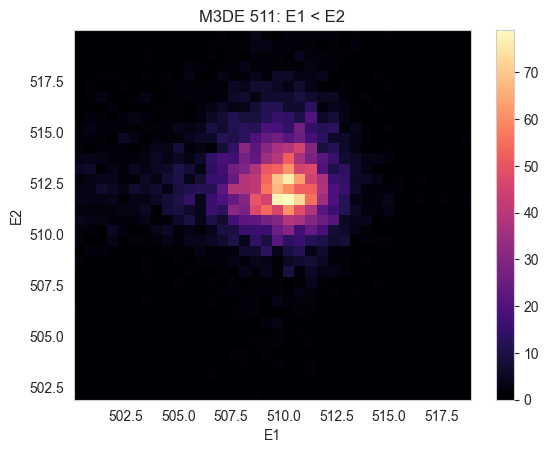

In [41]:
import random

e1 = []
e2 = []

for i in range(len(dataframe_reduced_double)):
    e1.append(dataframe_reduced_double.iloc[i,9][0])
    e2.append(dataframe_reduced_double.iloc[i,9][1])
    
np.random.shuffle(e1)
np.random.shuffle(e2)
    
plt.hist2d(e1, e2, bins=(2*int(max(e1)-min(e1)), 2*int(max(e1)-min(e1))), cmap='magma') 
plt.colorbar()
plt.ylabel('E2')
plt.xlabel('E1')
plt.title('M3DE 511: E1 < E2')

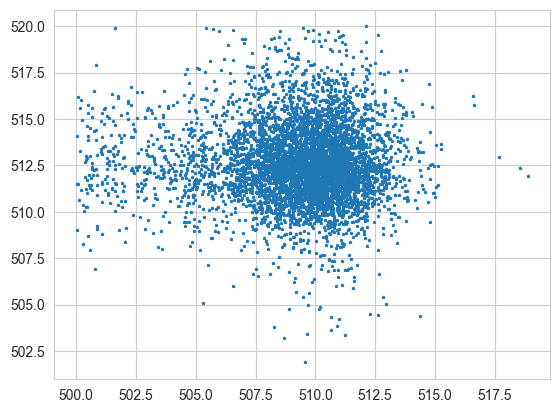

In [37]:
plt.scatter(e1, e2, marker = '*', s = 3)

In [6]:
NTD_double, no_NTD_double = NTD_Sort(dataframe_reduced_double)
FC, CE, NC, FN, NE, FF, CC, EE, NN, FE, O = Topology_Sort(no_NTD_double)
nonNTD_1600, nonNTD_511  = PrimarySecondarySplit(no_NTD_double)

NTD_1600, NTD_511 = PrimarySecondarySplit(NTD_double)
FC_NTD, CE_NTD, NC_NTD, FN_NTD, NE_NTD, FF_NTD, CC_NTD, EE_NTD, NN_NTD, FE_NTD, O_NTD = Topology_Sort(NTD_double)

In [7]:
def TripleGaussian(x,mu1,mu2,mu3, sigma, c2,c3):
    return (1-c2-c3)*norm.pdf(x,mu1,sigma)+c2*norm.pdf(x,mu2,sigma)+c3*norm.pdf(x,mu3,sigma)


def Residual_Plot(data, arr, bin_num):
    # bin_num = int(max(data) - min(data))
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]

    fitted_pdf = TripleGaussian(filtered_bin_centers, *arr)*len(data)*bin_width
    
    return filtered_bin_centers, (filtered_hist - fitted_pdf)/np.sqrt(filtered_hist), np.sqrt(filtered_hist)

def Chi2(data, arr, bin_num):
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    non_zero_indices = hist > 0
    filtered_hist = hist[non_zero_indices]
    filtered_bin_centers = bin_centers[non_zero_indices]

    fitted_pdf = TripleGaussian(filtered_bin_centers, *arr)*len(data)*bin_width

    chi2 = np.sum((filtered_hist-fitted_pdf)**2/fitted_pdf)
    
    return chi2

def PValue(dof, chi2):
    return 1-(sc.gammainc(dof/2, chi2/2))

def Minimizer(data, initial_parms, title, bin_num):
    c = cost.UnbinnedNLL(data, TripleGaussian)

    m = Minuit(c, *initial_parms)
    m.limits["c2", 'c3'] = (0, 1)
    m.limits["mu1", 'mu2', 'mu3', "sigma"] = (0, None)

    m.migrad()
    m.hesse()

    x_values = np.linspace(min(data), max(data), 1000)
    bin_width = (max(data) - min(data))/bin_num

    fig = plt.figure()
    ax=fig.add_axes((.1,.3,.8,.6))
    
    props = dict(boxstyle='round', facecolor='whitesmoke', alpha=0.5)
    text = '\n'.join(( r'$\Delta\chi^2/ndf= $' + str(np.round(Chi2(data, m.values, bin_num), decimals=2)) +'/' +str(bin_num - (TripleGaussian.__code__.co_argcount -1), ),
                    r'$P(ndf,\chi^2)=%.2f$' % (PValue(bin_num - (TripleGaussian.__code__.co_argcount -1),Chi2(data, m.values, bin_num)), ),
        'Entries: ' + (str(len(data))),
        r'$\mu_1=$ ' + str(np.round(m.values[0], decimals = 2) ) + '+-'+ str(np.round(m.errors[0], decimals = 2) ),
        r'$\mu_2=$ ' + str(np.round(m.values[1], decimals=2) ) + '+-'+ str(np.round(m.errors[1], decimals=2) ),
        r'$\mu_3=$ ' + str(np.round(m.values[2], decimals = 2) ) + '+-'+ str(np.round(m.errors[2], decimals = 2) ),
        r'$\sigma=$ ' + str(np.round(m.values[3], decimals = 2) ) + '+-'+ str(np.round(m.errors[3], decimals = 2) ),
        r'$c_2=$ ' + str(np.format_float_scientific(m.values[4], precision = 2) ) + '+-'+ str(np.format_float_scientific(m.errors[4], precision = 2) ),
        r'$c_3=$ ' + str(np.format_float_scientific(m.values[5], precision = 2) ) + '+-'+ str(np.format_float_scientific(m.errors[5], precision = 2) )
        ))
        
    mu1,mu2,mu3, sigma, c2,c3 = m.values

    ax.hist(data, bins = bin_num , histtype="step");
    ax.plot(x_values, TripleGaussian(x_values,*m.values)*len(data)*bin_width,label='Fitted PDF', color='#000272')
    ax.plot(x_values, (1-c2-c3)*norm.pdf(x_values,mu1,sigma)*len(data)*bin_width, label='Gaussian 1', linestyle='--', color = '#A72693')
    ax.plot(x_values, c2*norm.pdf(x_values,mu2,sigma)*len(data)*bin_width, label='Gaussian 2', linestyle='--', color='#02383C')
    ax.plot(x_values, c3*norm.pdf(x_values,mu3,sigma)*len(data)*bin_width, label='Gaussian 3', linestyle='--', color='#615DEC')
    ax.text(0.03, 0.95, text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
    ax.legend()

    ax2=fig.add_axes((.1,.08,.8,.2))        
    ax2.errorbar(Residual_Plot(data, m.values, bin_num)[0],Residual_Plot(data, m.values, bin_num)[1], fmt='o',markersize=4)
    ax2.axhline(0, linestyle='--', color='crimson')
    ax.set_title(title)
    
    return mu1, m.errors[0], sigma, m.errors[3], Chi2(data, m.values,bin_num)

def MinimizerTopologies(data, topologies, initial_parms, wid, height, figwidth, figheight):
    fitarr = []
    errorarr = []
    PDFs = []
    guass1 = []
    guass2 = []
    guass3 = []
    xvals = []
    bin_num = []
    bin_width = []

    for i in range(len(data)):
        E0 = min(data[i])
        E1 = max(data[i])
        c = cost.UnbinnedNLL(data[i], TripleGaussian)
        m = Minuit(c,*initial_parms[i])
        m.limits["c2", "c3"] = (0, 1)
        m.limits["mu1", 'mu2', 'sigma'] = (0, None)
        m.migrad()
        m.hesse()
        
        fitarr.append(m.values)
        errorarr.append(m.errors)
        x_values = np.linspace(min(data[i]), max(data[i]), 1000)
        xvals.append(x_values)
        bin_num.append(int(E1-E0))
        
        bin_width.append((E1-E0)/(int(E1-E0)))

    chisq = []
    pvals = []
    means1 = []
    means2 = []
    means3 = []
    sigmas = []
    c2 = []
    c3 = []

    means1err = []
    means2err = []
    means3err = []
    sigmaserr = []
    c2err= []
    c3err = []
        
    for i in range(len(fitarr)):
        E0 = min(data[i])
        E1 = max(data[i])
        PDFs.append(TripleGaussian(xvals[i],*fitarr[i])*len(data[i])*bin_width[i])
        guass1.append((1-fitarr[i][4]-fitarr[i][5])*norm.pdf(xvals[i],fitarr[i][0], fitarr[i][3])*len(data[i])*bin_width[i])
        guass2.append((fitarr[i][4])*norm.pdf(xvals[i],fitarr[i][1], fitarr[i][3])*len(data[i])*bin_width[i])
        guass3.append(fitarr[i][5]*norm.pdf(xvals[i], fitarr[i][2], fitarr[i][3])*len(data[i])*bin_width[i])
        chisq.append(Chi2(data[i], fitarr[i], bin_num[i]))
        pvals.append(PValue(bin_num[i]-(TripleGaussian.__code__.co_argcount -1), chisq[i]))
        
        means1.append(fitarr[i][0])
        means2.append(fitarr[i][1])
        means3.append(fitarr[i][2])
        sigmas.append(fitarr[i][3])
        c2.append(fitarr[i][4])
        c3.append(fitarr[i][5])
        
        means1err.append(errorarr[i][0])
        means2err.append(errorarr[i][1])
        means3err.append(errorarr[i][2])
        sigmaserr.append(errorarr[i][3])
        c2err.append(errorarr[i][4])
        c3err.append(errorarr[i][5])
        
        
        
    data = { 'Topologies': topologies,
        'Bin Num': bin_num,
    'Histogram Data': data,
        'X-axis': xvals,
        'Fit': PDFs,
        'Guass1': guass1,
        'Guass2': guass2,
        'Guass3': guass3,
        'means1': means1,
        'means2': means2,
        'means3': means3,
        'Sigmas': sigmas,
        'c2': c2,
        'c3': c3, 
        'Chi2': chisq,
        'p-value': pvals, 
        'means1err': means1err,
        'means2err': means2err,
        'means3err': means3err,
        'Sigmaserr': sigmaserr,
        'c2err': c2err,
        'c3err': c3err}

    df = pd.DataFrame(data)
        
    fig, axs = plt.subplots(wid, height, figsize=(figwidth, figheight))
    props = dict(boxstyle='round', facecolor='whitesmoke')
    for i, ax in enumerate(axs.flatten()):
        if i < len(df):
            divider = make_axes_locatable(ax)
            
            text = '\n'.join(( r'$\Delta\chi^2/ndf= $' + str(np.round(df['Chi2'][i], decimals=2)) +'/' +str(df['Bin Num'][i] - (TripleGaussian.__code__.co_argcount -1), ),
                    r'$P(ndf,\chi^2)=%.2f$' % (df['p-value'][i], ),
        'Entries: ' + (str(len(df['Histogram Data'][i]))),
        r'$\mu=$ ' + str(np.round(df['means1'][i], decimals = 2) ) + '+-'+ str(np.round(df['means1err'][i], decimals = 2) ),
        r'$\mu_2=$ ' + str(np.round(df['means2'][i], decimals=2) ) + '+-'+ str(np.round(df['means2err'][i], decimals=2) ),
        r'$\mu_3=$ ' + str(np.round(df['means3'][i], decimals=2) ) + '+-'+ str(np.round(df['means3err'][i], decimals=2) ),
        r'$\sigma=$ ' + str(np.round(df['Sigmas'][i], decimals = 2) ) + '+-'+ str(np.round(df['Sigmaserr'][i], decimals = 2) ),
        r'$c_2=$ ' + str(np.format_float_scientific(df['c2'][i], precision = 2) ) + '+-'+ str(np.format_float_scientific(df['c2err'][i], precision = 2) ),
        r'$c_3=$ ' + str(np.format_float_scientific(df['c3'][i], precision = 2) ) + '+-'+ str(np.format_float_scientific(df['c3err'][i], precision = 2) )
        ))
            
            ax.text(0.03, 0.95, text, transform=ax.transAxes, fontsize=7, verticalalignment='top', bbox=props)
            
            ax.hist(df['Histogram Data'][i], bins=df['Bin Num'][i], histtype="step")
            ax.plot(df['X-axis'][i], df['Fit'][i], label='Fitted PDF', color='#000272')
            ax.plot(df['X-axis'][i], df['Guass1'][i], label='Gaussian 1', linestyle='--', color = '#A72693')
            ax.plot(df['X-axis'][i], df['Guass2'][i], label='Gaussian 2', linestyle='--', color='#02383C')
            ax.plot(df['X-axis'][i], df['Guass3'][i], label='Gaussian 3', linestyle='--', color='#615DEC')
            ax.set_title(df["Topologies"][i])
            ax.legend(fontsize=8)
            
            ax2 = divider.append_axes("bottom", size="30%", pad=0.05)
            ax.figure.add_axes(ax2)
            ax2.errorbar(Residual_Plot(df['Histogram Data'][i], fitarr[i], bin_num[i])[0],Residual_Plot(df['Histogram Data'][i], fitarr[i], bin_num[i])[1], fmt='o',markersize=4)
            ax2.axhline(0, linestyle='--', color='crimson')
            
    plt.tight_layout()
    plt.show()
    
    return df
    

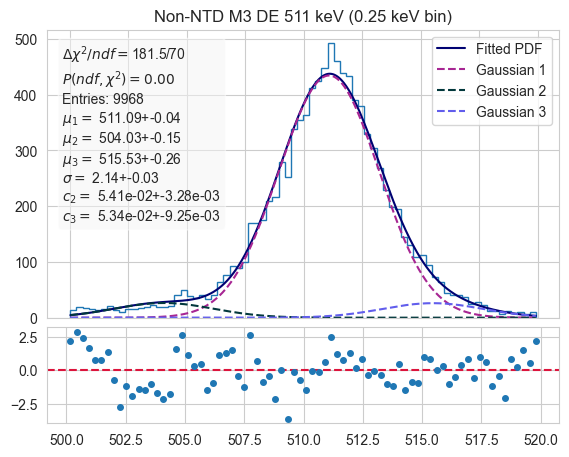

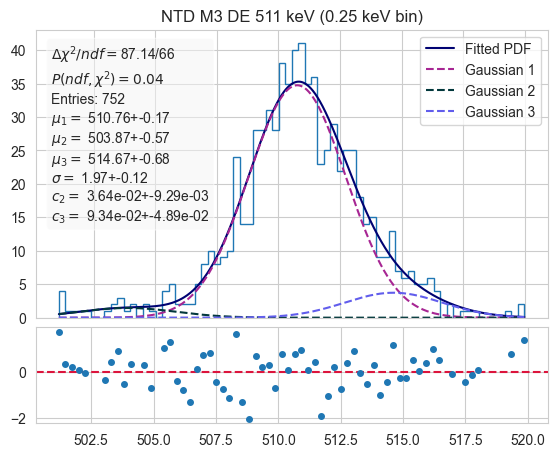

In [8]:
nonNTDmu, nonNTDmu_err, nonNTDsigma, nonNTDsigmaerr, nonNTDchi2=Minimizer(nonNTD_511, [511, 506, 516,2,0.3,0.1], 'Non-NTD M3 DE 511 keV (0.25 keV bin)', 4*int(max(nonNTD_511) - min(nonNTD_511)))
NTDmu, NTDmu_err, NTDsigma, NTDsigmaerr, NTDchi2=Minimizer(NTD_511, [511, 506, 516,2,0.3,0.1], 'NTD M3 DE 511 keV (0.25 keV bin)', 4*int(max(NTD_511) - min(NTD_511)))

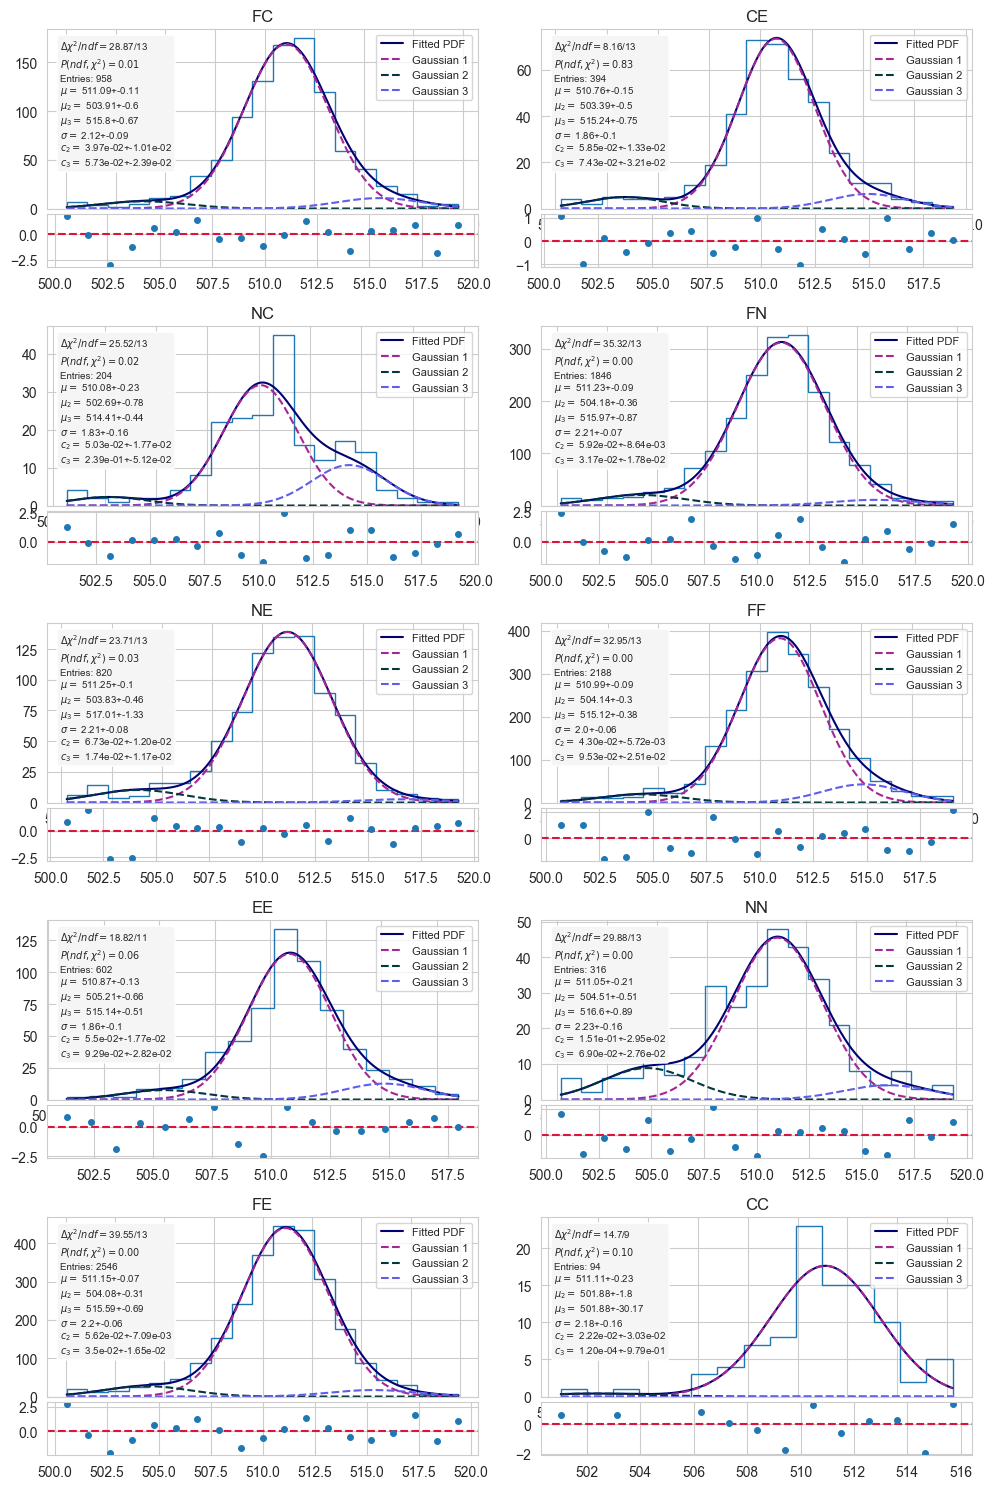

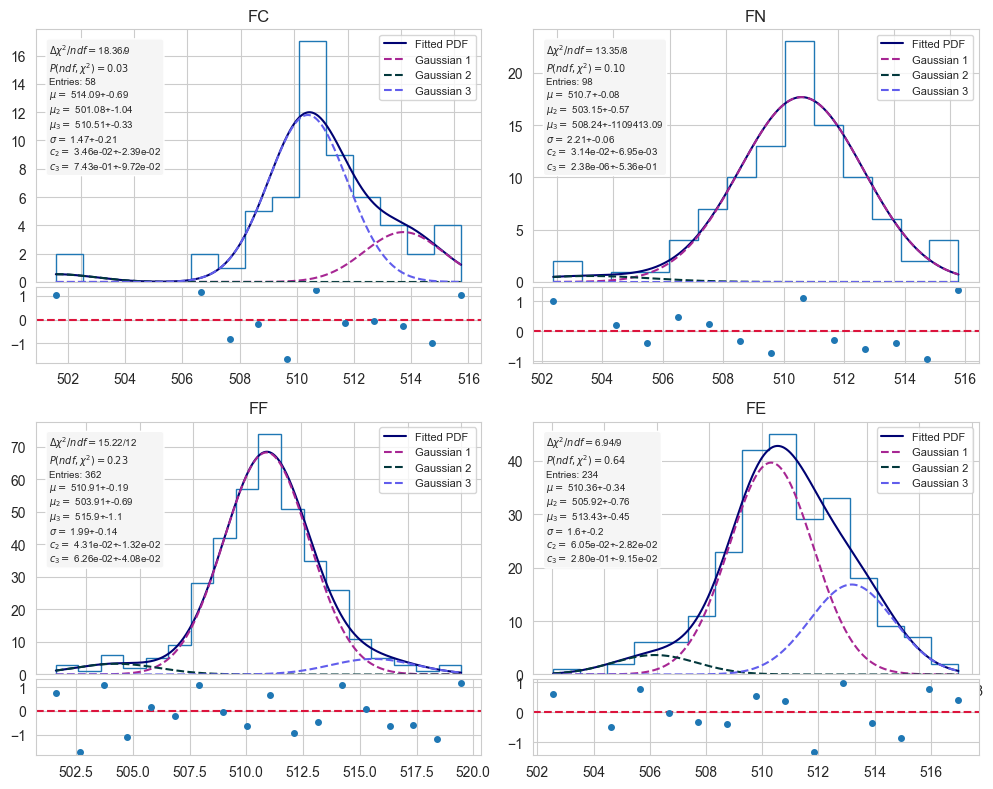

In [9]:
FC_1600, FC_1022 = PrimarySecondarySplit(FC)
CE_1600, CE_1022 = PrimarySecondarySplit(CE)
NC_1600, NC_1022 = PrimarySecondarySplit(NC)
FN_1600, FN_1022 = PrimarySecondarySplit(FN)
NE_1600, NE_1022 = PrimarySecondarySplit(NE)
FF_1600, FF_1022 = PrimarySecondarySplit(FF)
CC_1600, CC_1022 = PrimarySecondarySplit(CC)
EE_1600, EE_1022 = PrimarySecondarySplit(EE)
NN_1600, NN_1022 = PrimarySecondarySplit(NN)
FE_1600, FE_1022 = PrimarySecondarySplit(FE)

FC_1600NTD, FC_1022NTD = PrimarySecondarySplit(FC_NTD)
FN_1600NTD, FN_1022NTD = PrimarySecondarySplit(FN_NTD)
FF_1600NTD, FF_1022NTD = PrimarySecondarySplit(FF_NTD)
FE_1600NTD, FE_1022NTD = PrimarySecondarySplit(FE_NTD)

FC_initial_1022 = [511, 506, 516, 2.3171847521755162, 0.1, 0.1]
CE_initial_1022 = [511, 506, 516, 1.8512685822217934, 0.01, 0.01]
NC_initial_1022 = [511, 506, 516, 2.4615818104711433, 0.1, 0.01]
FN_initial_1022 = [511, 506, 516, 2.536260729120265, 0.1, 0.1]
NE_initial_1022 = [506,516,511, 2.888842503381022, 0.1, 0.01]
FF_initial_1022 = [511, 506, 516, 2.660575293091914, 0.1, 0.01]
EE_initial_1022= [511, 506, 516, 2.4769928244708357, 0.1, 0.01]
NN_initial_1022= [511, 506, 516, 2.6052131244724173, 0.1, 0.5]
FE_initial_1022= [511, 506, 516, 2.655431371739795, 0.1, 0.01]
CC_initial_1022= [np.mean(CC_1022), 506, 516, np.std(CC_1022), 0.1, 0.01]

FE_initial_1022NTD= [511, 506, 516, 2.655431371739795, 0.05, 0.2]
FN_initial_1022NTD = [511, 506, 516, 2.536260729120265, 0.1, 0.01]


hist_data = [FC_1022, CE_1022, NC_1022, FN_1022, NE_1022, FF_1022, EE_1022, NN_1022, FE_1022, CC_1022]
initial_parms = [FC_initial_1022, CE_initial_1022, NC_initial_1022, FN_initial_1022, NE_initial_1022, FF_initial_1022, EE_initial_1022, NN_initial_1022, FE_initial_1022, CC_initial_1022]
topologies = ['FC', 'CE', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE', 'CC']

df = MinimizerTopologies(hist_data, topologies, initial_parms, 5, 2, 10, 15)

hist_dataNTD = [FC_1022NTD, FN_1022NTD, FF_1022NTD, FE_1022NTD]
initial_parmsNTD = [FC_initial_1022, FN_initial_1022NTD, FF_initial_1022, FE_initial_1022NTD]
topologiesNTD = ['FC', 'FN', 'FF','FE']

dfNTD = MinimizerTopologies(hist_dataNTD, topologiesNTD, initial_parmsNTD, 2, 2, 10, 8)

In [10]:
def ExpectedVals(total_dataframe, dataframe):
        weights = [(((len(total_dataframe[total_dataframe['Dataset']==3801]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3801]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3802]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3802]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3803]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3803]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3804]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3804]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3805]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3805]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3806]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3806]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3807]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3807]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3808]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3808]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3809]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3809]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3810]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3810]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3811]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3811]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3812]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3812]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3813]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3813]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3814]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3814]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3815]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3815]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3816]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3816]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3817]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3817]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3818]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3818]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3819]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3819]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3820]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3820]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3821]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3821]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3822]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3822]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3823]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3823]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3824]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3824]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3825]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3825]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3826]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3826]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3827]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3827]))/len(dataframe))*100),
                   (((len(total_dataframe[total_dataframe['Dataset']==3828]))/len(total_dataframe))*100)/(((len(dataframe[dataframe['Dataset']==3828]))/len(dataframe))*100),
                   ]
        
        df_bias = pd.read_csv('Dataset-Info-ResBias/M3DE511_bias_all.txt', sep=',', names=['Dataset', 'Bias', 'Bias_err'], header=None)
        df_res = pd.read_csv('Dataset-Info-ResBias/M3DE511_reso_all.txt', sep=',', names=['Dataset', 'Res', 'Res_err'], header=None)
        
        mean_bias = 0
        sigma_res = 0
        
        for i in range(len(weights)):
                mean_bias += weights[i]*df_bias.iloc[i+1,1]
                sigma_res += weights[i]*df_res.iloc[i+1,1]
                
        average_means_bias = mean_bias/sum(weights)
        average_sigma_res = sigma_res/sum(weights)
        
        mean_bias_err = 0
        sigma_res_err = 0
        
        for i in range(len(weights)):
                mean_bias_err += (weights[i]*df_bias.iloc[i+1,2])**2
                sigma_res_err += (weights[i]*df_res.iloc[i+1,2])**2
        
        actual_mean_err = 1/sum(weights)*np.sqrt(mean_bias_err)
        actual_sigma_err = 1/sum(weights)*np.sqrt(sigma_res_err)
        
        
        return average_means_bias, (average_sigma_res/2.355), actual_mean_err, actual_sigma_err*(1/2.355)

In [11]:
mean_bias, sigma, meanerr, sigmaerr = ExpectedVals(dataframe_reduced_double, dataframe_reduced_double)

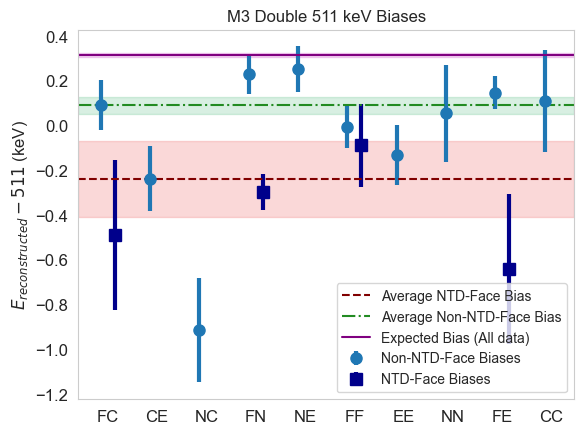

In [12]:
fig, ax = plt.subplots()
trans1 = Affine2D().translate(-0.14, 0.0) + ax.transData
trans2 = Affine2D().translate(+0.14, 0.0) + ax.transData

NTDmeans = [dfNTD['means3'][0], dfNTD['means1'][1], dfNTD['means1'][2], dfNTD['means1'][3]]
NTDmeanserr = [dfNTD['means3err'][0], dfNTD['means1err'][1], dfNTD['means1err'][2], dfNTD['means1err'][3]]

ax.errorbar(topologies, df['means1']-511, yerr=df['means1err'], transform=trans1, ms=8, elinewidth=3, fmt='o', label='Non-NTD-Face Biases')
ax.errorbar(topologiesNTD, np.asarray(NTDmeans)-511, yerr=NTDmeanserr, transform=trans2,fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD-Face Biases')

ax.axhspan(NTDmu-511-NTDmu_err, NTDmu-511+NTDmu_err, color='lightcoral', alpha=0.3)
ax.axhline(NTDmu-511, color='maroon', linestyle='--', label='Average NTD-Face Bias')

ax.axhspan(nonNTDmu-511-nonNTDmu_err, nonNTDmu-511+nonNTDmu_err, color='mediumseagreen', alpha=0.2)
ax.axhline(nonNTDmu-511, color='forestgreen', linestyle='-.', label='Average Non-NTD-Face Bias')

ax.legend(fontsize=10, loc='lower right')

ax.axhspan(mean_bias + meanerr, mean_bias - meanerr, color='orchid', alpha=0.3)
ax.axhline(mean_bias, color='purple', linestyle='-', label='Expected Bias (All data)')

ax.set_ylabel(r'$E_{reconstructed}-511$ (keV)', fontsize=12)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 Double 511 keV Biases')
plt.legend()


Text(0.5, 1.0, 'M3 Double 511 keV Sigmas')

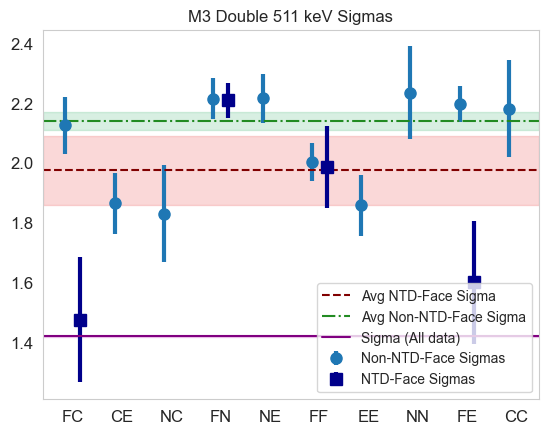

In [13]:
fig, ax = plt.subplots()
trans1 = Affine2D().translate(-0.15, 0.0) + ax.transData
trans2 = Affine2D().translate(+0.15, 0.0) + ax.transData

ax.errorbar(topologies, df['Sigmas'], yerr=df['Sigmaserr'], transform=trans1, ms=8, elinewidth=3, fmt='o', label='Non-NTD-Face Sigmas')
ax.errorbar(topologiesNTD, dfNTD['Sigmas'], yerr=dfNTD['Sigmaserr'], transform=trans2,fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD-Face Sigmas')

ax.axhspan(NTDsigma-NTDsigmaerr, NTDsigma+NTDsigmaerr, color='lightcoral', alpha=0.3)
ax.axhline(NTDsigma, color='maroon', linestyle='--', label='Avg NTD-Face Sigma')

ax.axhspan(nonNTDsigma-nonNTDsigmaerr, nonNTDsigma+nonNTDsigmaerr, color='mediumseagreen', alpha=0.2)
ax.axhline(nonNTDsigma, color='forestgreen', linestyle='-.', label='Avg Non-NTD-Face Sigma')

ax.axhspan(sigma + sigmaerr, sigma - sigmaerr, color='orchid', alpha=0.3)
ax.axhline(sigma, color='purple', linestyle='-', label='Sigma (All data)')

ax.legend(fontsize=10, loc='lower right')

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 Double 511 keV Sigmas')

In [14]:
for i in range(len(NTDmeans)):
    print('NTD:'+ str(topologiesNTD[i])+ ' ' +str(NTDmeans[i]-511) + '+-' + str(NTDmeanserr[i]))
    
for i in range(len(df['means1'])):
    print(str(topologies[i])+' '+str(df['means1'][i]-511) + '+-' + str(df['means1err'][i]))

NTD:FC -0.48995832307235787+-0.3346538893536614
NTD:FN -0.2981262585371951+-0.08087528349722106
NTD:FF -0.08871957403198394+-0.1850629983827048
NTD:FE -0.6431373529194957+-0.3355091324517616
FC 0.0927642954861767+-0.11267635775874396
CE -0.23838701006621932+-0.1454646996657516
NC -0.9157677381143117+-0.23267233297971757
FN 0.22860715608021565+-0.08713854010130717
NE 0.25227925205297197+-0.10120022017713382
FF -0.005250561563116207+-0.09316686683581565
EE -0.13093221291711643+-0.13344403049728726
NN 0.053921615038348136+-0.21473385640223341
FE 0.14715398922078293+-0.07484615278434603
CC 0.10961544180918281+-0.22902097009375666


In [15]:
for i in range(len(dfNTD['Sigmas'])):
    print('NTD:'+ str(topologiesNTD[i])+ ' ' +str(dfNTD['Sigmas'][i]) + '+-' + str(dfNTD['Sigmaserr'][i]))
    
for i in range(len(df['Sigmas'])):
    print(str(topologies[i])+' '+str(df['Sigmas'][i]) + '+-' + str(df['Sigmaserr'][i]))

NTD:FC 1.4744478745255227+-0.20937019212089614
NTD:FN 2.2086671077225684+-0.0591117426339649
NTD:FF 1.9861468013854484+-0.13716283005578078
NTD:FE 1.5998080908000554+-0.20480596818500096
FC 2.1245510498077844+-0.09472798739820654
CE 1.8638008254169747+-0.10133946837349339
NC 1.8300864678530009+-0.16126284677267377
FN 2.213863839220678+-0.06829512543948968
NE 2.214657045501889+-0.08069789108362113
FF 2.0033266395364264+-0.06333863671501017
EE 1.8580580093650814+-0.10173509869669539
NN 2.2333020652266256+-0.1552674788232069
FE 2.195117933807732+-0.05976934262054767
CC 2.1808813186326432+-0.1619132724939638


In [16]:
print(mean_bias)
print(meanerr)
print(sigma)
print(sigmaerr)

0.31657142857142845
0.009582083621562286
1.4188260539884743
0.00035246458506773377
